<a href="https://colab.research.google.com/github/huwperkins08-lang/Desalination_outfall/blob/main/ee_api_colab_setup.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# New Section

import relevant libraries and upload raw data file as csv. Create pandas df.

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats

#import raw data to create pandas df and print first 5 rows to confirm succesfull upload
sea_data = pd.read_csv('perfiles_oceanograficos_master_final.csv')
sea_data.head()



,Profundidad (m),Aug25_Temp_Media,Aug25_Temp_SD,Aug25_Temp_Min,Aug25_Temp_Max,Aug25_Sal_Media,Aug25_Sal_SD,Aug25_Sal_Min,Aug25_Sal_Max,Aug25_Den_Media,...,Aug14_Sal_Min,Aug14_Sal_Max,Aug14_Den_Media,Aug14_Den_SD,Aug14_Den_Min,Aug14_Den_Max,Aug14_O2_Media,Aug14_O2_SD,Aug14_O2_Min,Aug14_O2_Max
0,1,15.6362,0.2676,14.8332,16.0148,34.6194,0.0163,34.5721,34.6545,25.5369,...,34.3552,34.4352,26.0115,0.0125,25.9415,26.0850,5.5115,0.1652,4.9415,6.0415
1,5,15.5098,0.2186,14.8651,15.9768,34.6365,0.0171,34.6083,34.6769,25.5788,...,34.3552,34.4552,26.0215,0.0095,25.9652,26.0652,5.4850,0.1415,4.8850,5.9850
2,10,15.4315,0.1849,14.8241,15.8378,34.6363,0.0117,34.6189,34.6684,25.5963,...,34.3850,34.4552,26.0415,0.0075,25.9850,26.0652,5.4115,0.1215,4.7850,5.9115
3,15,15.3362,0.2114,14.4758,15.4969,34.6381,0.0155,34.6167,34.6755,25.6190,...,34.3850,34.4652,26.0552,0.0065,25.9952,26.0850,5.2850,0.0985,4.5850,5.7850
4,20,15.2433,0.1634,14.7624,15.4373,34.6486,0.0275,34.6230,34.7193,25.6480,...,34.3952,34.4850,26.0652,0.0052,26.0115,26.0952,5.1115,0.1352,4.3850,5.6115


In [ ]:
#print df info to check correct datatypes
sea_data.info()
sea_data.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Columns: 305 entries, Profundidad (m) to Aug14_O2_Max
dtypes: float64(304), int64(1)
memory usage: 19.2 KB


Index(['Profundidad (m)', 'Aug25_Temp_Media', 'Aug25_Temp_SD',
       'Aug25_Temp_Min', 'Aug25_Temp_Max', 'Aug25_Sal_Media', 'Aug25_Sal_SD',
       'Aug25_Sal_Min', 'Aug25_Sal_Max', 'Aug25_Den_Media',
       ...
       'Aug14_Sal_Min', 'Aug14_Sal_Max', 'Aug14_Den_Media', 'Aug14_Den_SD',
       'Aug14_Den_Min', 'Aug14_Den_Max', 'Aug14_O2_Media', 'Aug14_O2_SD',
       'Aug14_O2_Min', 'Aug14_O2_Max'],
      dtype='object', length=305)

plot seasonal changes in salinity at range of depths

In [ ]:
# create secondary dataframe with salinity data for all Aug readings
aug_salinity_cols = [col for col in sea_data.columns if 'Aug' in col and 'Sal' in col]
aug_salinity_data = sea_data[['Profundidad (m)'] + aug_salinity_cols]
display(aug_salinity_data.head())

,Profundidad (m),Aug25_Sal_Media,Aug25_Sal_SD,Aug25_Sal_Min,Aug25_Sal_Max,Aug24_Sal_Media,Aug24_Sal_SD,Aug24_Sal_Min,Aug24_Sal_Max,Aug23_Sal_Media,...,Aug18_Sal_Min,Aug18_Sal_Max,Aug17_Sal_Media,Aug17_Sal_SD,Aug17_Sal_Min,Aug17_Sal_Max,Aug14_Sal_Media,Aug14_Sal_SD,Aug14_Sal_Min,Aug14_Sal_Max
0,1,34.6194,0.0163,34.5721,34.6545,34.5823,0.0061,34.5731,34.5998,34.5684,...,34.4115,34.4952,34.4115,0.0065,34.3850,34.4652,34.3850,0.0052,34.3552,34.4352
1,5,34.6365,0.0171,34.6083,34.6769,34.5756,0.0120,34.5455,34.5993,34.5714,...,34.4115,34.5115,34.4215,0.0075,34.3850,34.4850,34.3952,0.0065,34.3552,34.4552
2,10,34.6363,0.0117,34.6189,34.6684,34.5695,0.0186,34.5043,34.6031,34.5750,...,34.4552,34.5115,34.4552,0.0052,34.4115,34.4850,34.4215,0.0045,34.3850,34.4552
3,15,34.6381,0.0155,34.6167,34.6755,34.5693,0.0210,34.5455,34.6496,34.5800,...,34.4552,34.5215,34.4652,0.0045,34.4115,34.4952,34.4352,0.0035,34.3850,34.4652
4,20,34.6486,0.0275,34.6230,34.7193,34.5894,0.0782,34.5443,34.9260,34.5815,...,34.4652,34.5285,34.4850,0.0065,34.4215,34.5115,34.4552,0.0052,34.3952,34.4850


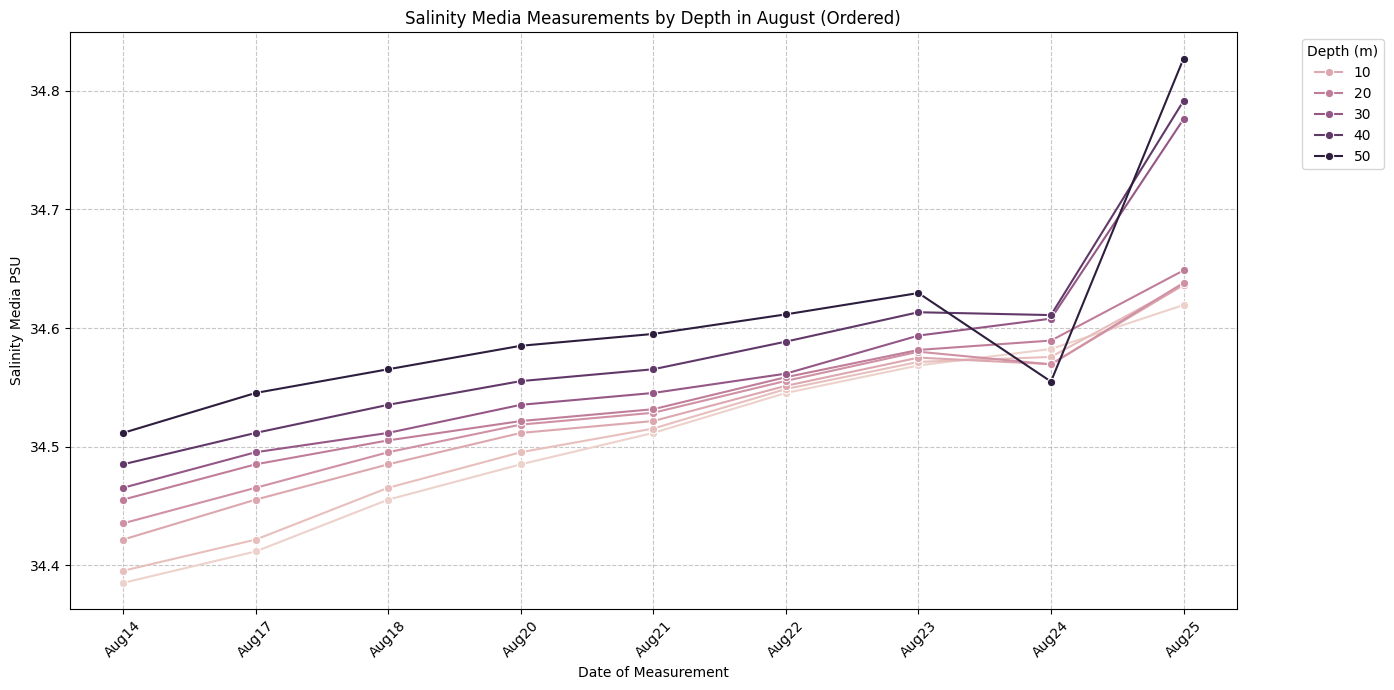

In [ ]:
salinity_media_cols = [col for col in aug_salinity_data.columns if 'Sal_Media' in col]

# Melt the DataFrame to long format for easier plotting
melted_salinity_data = aug_salinity_data.melt(
    id_vars=['Profundidad (m)'],
    value_vars=salinity_media_cols,
    var_name='Measurement_Date',
    value_name='Salinity'
)

# Extract the date part for better x-axis labels
melted_salinity_data['Date'] = melted_salinity_data['Measurement_Date'].apply(lambda x: x.split('_')[0])

# Define the custom order for the dates
date_order = ['Aug14', 'Aug17', 'Aug18', 'Aug20', 'Aug21', 'Aug22', 'Aug23', 'Aug24', 'Aug25']

# Convert 'Date' column to a Categorical type with the desired order
melted_salinity_data['Date'] = pd.Categorical(melted_salinity_data['Date'], categories=date_order, ordered=True)

plt.figure(figsize=(14, 7))
sns.lineplot(
    data=melted_salinity_data,
    x='Date',
    y='Salinity',
    hue='Profundidad (m)',
    marker='o' # Add markers for clarity
)

plt.title('Salinity Media Measurements by Depth in August (Ordered)')
plt.xlabel('Date of Measurement')
plt.ylabel('Salinity Media PSU')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45) # Rotate x-axis labels if they overlap
plt.legend(title='Depth (m)', bbox_to_anchor=(1.05, 1), loc='upper left') # Move legend outside to prevent overlapping
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

In [ ]:
# create secondary dataframe with salinity data for all Jan readings
jan_salinity_cols = [col for col in sea_data.columns if 'Jan' in col and 'Sal' in col]
jan_salinity_data = sea_data[['Profundidad (m)'] + jan_salinity_cols]
display(jan_salinity_data.head())

,Profundidad (m),Jan25_Sal_Media,Jan25_Sal_SD,Jan25_Sal_Min,Jan25_Sal_Max,Jan24_Sal_Media,Jan24_Sal_SD,Jan24_Sal_Min,Jan24_Sal_Max,Jan23_Sal_Media,...,Jan18_Sal_Min,Jan18_Sal_Max,Jan17_Sal_Media,Jan17_Sal_SD,Jan17_Sal_Min,Jan17_Sal_Max,Jan14_Sal_Media,Jan14_Sal_SD,Jan14_Sal_Min,Jan14_Sal_Max
0,1,34.6304,0.0201,34.5822,34.6637,34.798,0.0370,34.707,34.865,34.7115,...,34.6115,34.7215,34.5850,0.0125,34.5352,34.6552,34.5552,0.0115,34.5115,34.6215
1,5,34.5980,0.0566,34.4029,34.6802,34.778,0.0890,34.388,34.856,34.6985,...,34.4850,34.7552,34.5652,0.0215,34.4215,34.6850,34.5352,0.0185,34.3850,34.6552
2,10,34.6103,0.0638,34.3554,34.7052,34.747,0.0704,34.501,34.856,34.6854,...,34.4552,34.6952,34.5452,0.0315,34.3850,34.6215,34.5115,0.0265,34.3552,34.5950
3,15,34.6055,0.0381,34.5199,34.6683,34.667,0.1650,34.242,34.859,34.6552,...,34.3115,34.6850,34.5115,0.0515,34.2552,34.6115,34.4850,0.0452,34.2115,34.5850
4,20,34.5997,0.0701,34.4278,34.7919,34.720,0.2720,34.235,35.666,34.6415,...,34.1552,34.8115,34.4850,0.0652,34.1115,34.7215,34.4552,0.0585,34.0850,34.6952


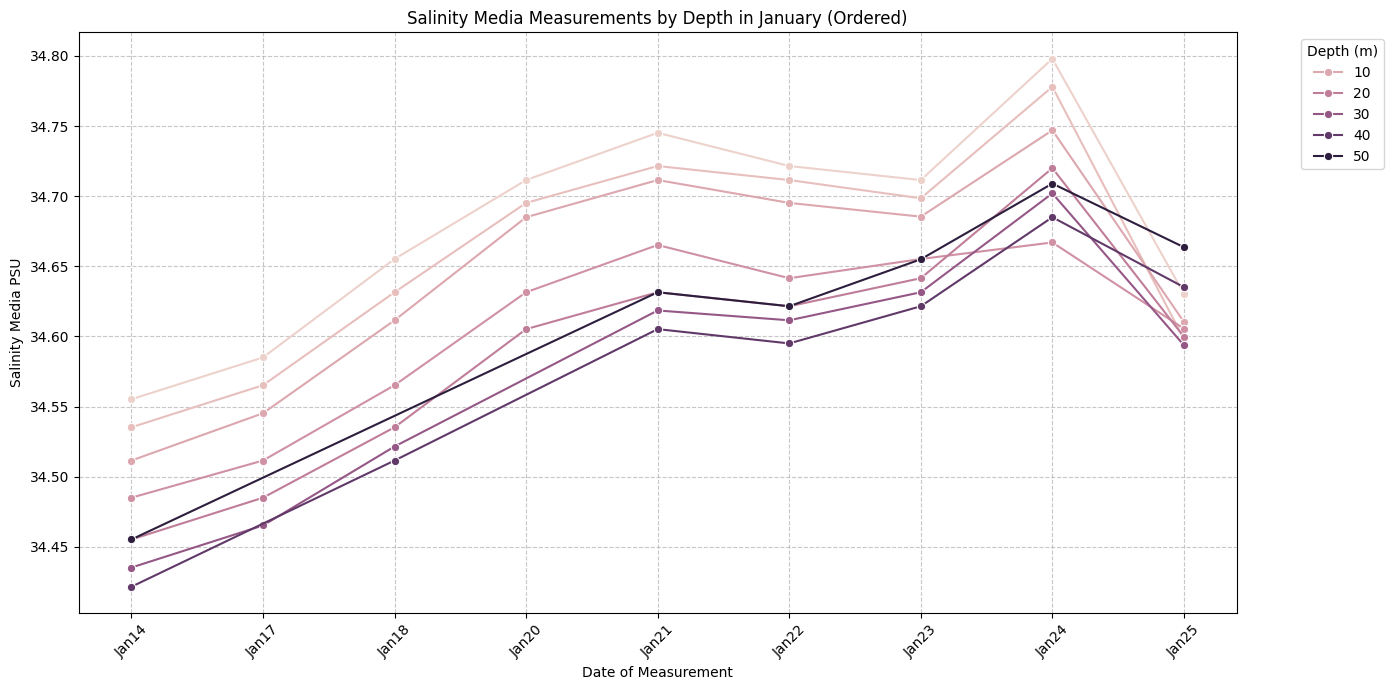

In [ ]:
salinity_media_cols_jan = [col for col in jan_salinity_data.columns if 'Sal_Media' in col]

# Melt the DataFrame to long format for easier plotting
melted_salinity_data = jan_salinity_data.melt(
    id_vars=['Profundidad (m)'],
    value_vars=salinity_media_cols_jan,
    var_name='Measurement_Date',
    value_name='Salinity'
)

# Extract the date part for better x-axis labels
melted_salinity_data['Date'] = melted_salinity_data['Measurement_Date'].apply(lambda x: x.split('_')[0])

# Define the custom order for the dates
date_order = ['Jan14', 'Jan17', 'Jan18', 'Jan20', 'Jan21', 'Jan22', 'Jan23', 'Jan24', 'Jan25']

# Convert 'Date' column to a Categorical type with the desired order
melted_salinity_data['Date'] = pd.Categorical(melted_salinity_data['Date'], categories=date_order, ordered=True)

plt.figure(figsize=(14, 7))
sns.lineplot(
    data=melted_salinity_data,
    x='Date',
    y='Salinity',
    hue='Profundidad (m)',
    marker='o' # Add markers for clarity
)

plt.title('Salinity Media Measurements by Depth in January (Ordered)')
plt.xlabel('Date of Measurement')
plt.ylabel('Salinity Media PSU')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45) # Rotate x-axis labels if they overlap
plt.legend(title='Depth (m)', bbox_to_anchor=(1.05, 1), loc='upper left') # Move legend outside to prevent overlapping
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

In [ ]:
import pandas as pd
import scipy.stats as stats

# 1. Clean up column headers just in case
sea_data.columns = sea_data.columns.str.strip()

print("==================================================")
print("     PROJECT NUMERICAL ANALYSIS: EMISSION ERAS     ")
print("==================================================\n")

# ---- WINTER ANALYSIS (Structured Plot) ----
winter_df = sea_data[['Profundidad (m)', 'Aug14_Sal_Media', 'Aug25_Sal_Media']].dropna()
w_stat, w_p = stats.wilcoxon(winter_df['Aug25_Sal_Media'], winter_df['Aug14_Sal_Media'])
w_diff = winter_df['Aug25_Sal_Media'].mean() - winter_df['Aug14_Sal_Media'].mean()

print(f"--- WINTER COHORT (August 2014 vs August 2025) ---")
print(f"  Data Points Paired: {len(winter_df)}")
print(f"  Mean Salinity Shift: {w_diff:+.3f} PSU")
print(f"  Wilcoxon p-value: {w_p:.6f}")
if w_p < 0.05:
    print("  => RESULT: Statistically Significant. The winter water column has shifted.")
else:
    print("  => RESULT: Not Significant. Inconclusive winter shift.")

print("\n" + "-"*50 + "\n")

# ---- SUMMER ANALYSIS (Messy Plot) ----
summer_df = sea_data[['Profundidad (m)', 'Jan14_Sal_Media', 'Jan25_Sal_Media']].dropna()
s_stat, s_p = stats.wilcoxon(summer_df['Jan25_Sal_Media'], summer_df['Jan14_Sal_Media'])
s_diff = summer_df['Jan25_Sal_Media'].mean() - summer_df['Jan14_Sal_Media'].mean()

print(f"--- SUMMER COHORT (January 2014 vs January 2025) ---")
print(f"  Data Points Paired: {len(summer_df)}")
print(f"  Mean Salinity Shift: {s_diff:+.3f} PSU")
print(f"  Wilcoxon p-value: {s_p:.6f}")
if s_p < 0.05:
    print("  => RESULT: Statistically Significant. Despite summer noise, a clear shift exists.")
else:
    print("  => RESULT: Not Significant. Summer variance masks the expansion signal.")

     PROJECT NUMERICAL ANALYSIS: EMISSION ERAS     

--- WINTER COHORT (August 2014 vs August 2025) ---
  Data Points Paired: 8
  Mean Salinity Shift: +0.253 PSU
  Wilcoxon p-value: 0.007812
  => RESULT: Statistically Significant. The winter water column has shifted.

--------------------------------------------------

--- SUMMER COHORT (January 2014 vs January 2025) ---
  Data Points Paired: 8
  Mean Salinity Shift: +0.135 PSU
  Wilcoxon p-value: 0.007812
  => RESULT: Statistically Significant. Despite summer noise, a clear shift exists.
